# 06 · 樣式與美學：style、rcParams、colormap、中文字型

最後一課，把圖從「能看」升級到「好看又專業」。重點包含一個華語使用者一定會踩到的坑：**中文顯示成豆腐 □□□**——這課一次解決。

> 💡 可執行 notebook，`Shift+Enter` 跑每一格。

## 學習目標

- 一行套用內建 **style sheet** 改變整體風格
- 用 **rcParams** 設定全域預設（字級、線粗、格線…）
- 用 **colormap** 為連續數值上色
- 解決 matplotlib 的**中文字型**問題

## 1. style sheet：一行換風格

matplotlib 內建好幾套現成風格。先看有哪些可用：

In [1]:
import matplotlib.pyplot as plt
import numpy as np

print(plt.style.available)   # 列出所有可用 style

['Solarize_Light2', '_classic_test_patch', '_mpl-gallery', '_mpl-gallery-nogrid', 'bmh', 'classic', 'dark_background', 'fast', 'fivethirtyeight', 'ggplot', 'grayscale', 'petroff10', 'seaborn-v0_8', 'seaborn-v0_8-bright', 'seaborn-v0_8-colorblind', 'seaborn-v0_8-dark', 'seaborn-v0_8-dark-palette', 'seaborn-v0_8-darkgrid', 'seaborn-v0_8-deep', 'seaborn-v0_8-muted', 'seaborn-v0_8-notebook', 'seaborn-v0_8-paper', 'seaborn-v0_8-pastel', 'seaborn-v0_8-poster', 'seaborn-v0_8-talk', 'seaborn-v0_8-ticks', 'seaborn-v0_8-white', 'seaborn-v0_8-whitegrid', 'tableau-colorblind10']


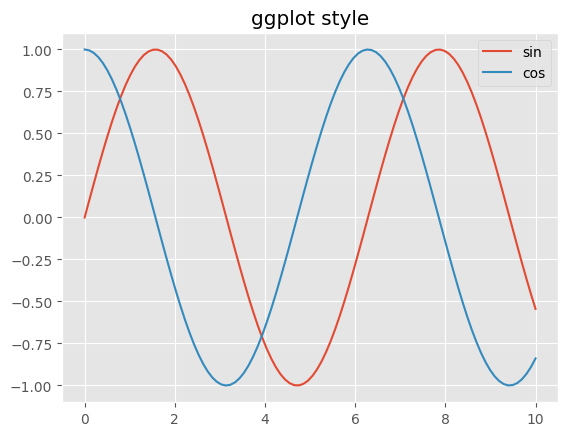

In [2]:
x = np.linspace(0, 10, 100)

# 在 with 區塊內套用 style，離開區塊就恢復預設（不污染其他圖）
with plt.style.context("ggplot"):
    fig, ax = plt.subplots()
    ax.plot(x, np.sin(x), label="sin")
    ax.plot(x, np.cos(x), label="cos")
    ax.legend()
    ax.set_title("ggplot style")
    plt.show()

**動手試試**：把 `"ggplot"` 換成 `"seaborn-v0_8"`、`"bmh"`、`"fivethirtyeight"`、`"dark_background"` 各跑一次。

## 2. rcParams：調全域預設

`rcParams` 是 matplotlib 的全域設定字典。改了它，**之後畫的每張圖**都套用。

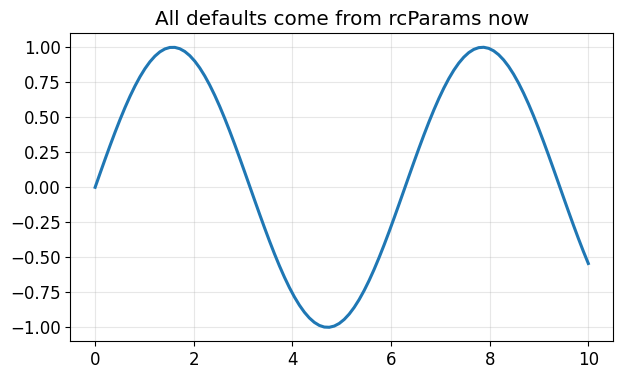

In [3]:
plt.rcParams["figure.figsize"] = (7, 4)
plt.rcParams["axes.grid"] = True          # 預設開格線
plt.rcParams["grid.alpha"] = 0.3
plt.rcParams["lines.linewidth"] = 2.2
plt.rcParams["font.size"] = 12

fig, ax = plt.subplots()
ax.plot(x, np.sin(x))
ax.set_title("All defaults come from rcParams now")
plt.show()

## 3. colormap：用顏色表達第三個維度

散佈圖的點除了 (x, y)，還能用顏色 `c` 表達第三個數值，`cmap` 指定色盤。`colorbar` 補上對照尺。

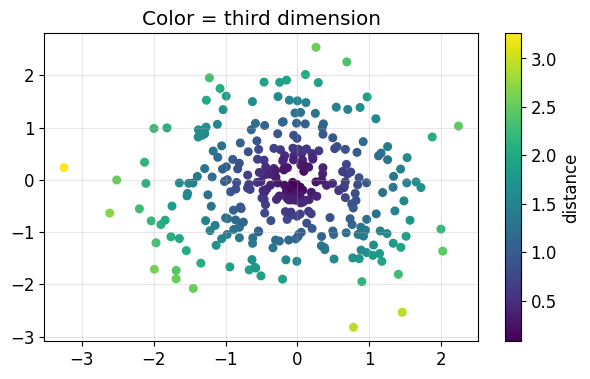

In [4]:
rng = np.random.default_rng(7)
n = 300
xx = rng.normal(0, 1, n)
yy = rng.normal(0, 1, n)
dist = np.sqrt(xx**2 + yy**2)        # 第三維：離原點距離

fig, ax = plt.subplots()
sc = ax.scatter(xx, yy, c=dist, cmap="viridis", s=30)
fig.colorbar(sc, ax=ax, label="distance")
ax.set_title("Color = third dimension")
plt.show()

> 小提醒：選 colormap 時優先用 `viridis`、`plasma`、`cividis` 這類「感知均勻」的色盤，避免用 `jet`——它會製造不存在的視覺邊界，也對色盲不友善。

## 4. 中文字型：解決豆腐 □□□

matplotlib 預設字型沒有中文字，所以中文會變方塊。解法是告訴它去用一個含中文的字型。

**在 Colab**（沒有內建中文字型），先安裝一套，再設定：

```python
# 在 Colab 執行一次即可（前面加驚嘆號是 shell 指令）
!apt-get -qq install fonts-noto-cjk > /dev/null
```

安裝完（或在本機已有中文字型時），執行下面這段設定：

使用字型: Heiti TC


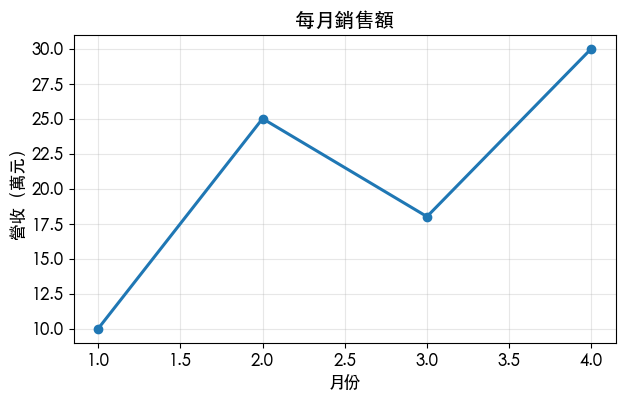

In [5]:
import matplotlib
from matplotlib import font_manager

# 候選字型：依序嘗試，用到第一個系統裝得到的。
# Colab 裝了 fonts-noto-cjk 後會有 'Noto Sans CJK TC/JP'。
candidates = [
    "Noto Sans CJK TC", "Noto Sans CJK JP",   # Linux / Colab
    "PingFang TC", "Heiti TC", "Arial Unicode MS",  # macOS
    "Microsoft JhengHei",                       # Windows
]
installed = {f.name for f in font_manager.fontManager.ttflist}
chosen = next((c for c in candidates if c in installed), None)
print("使用字型:", chosen)

if chosen:
    matplotlib.rcParams["font.sans-serif"] = [chosen]
matplotlib.rcParams["axes.unicode_minus"] = False   # 修正負號變方塊

fig, ax = plt.subplots()
ax.plot([1, 2, 3, 4], [10, 25, 18, 30], marker="o")
ax.set_title("每月銷售額")
ax.set_xlabel("月份")
ax.set_ylabel("營收（萬元）")
plt.show()

兩個常見地雷：

1. **`axes.unicode_minus = False`** 一定要設，否則負號 `−` 也會變成方塊。
2. 設了字型還是方塊？通常是字型名稱拼錯，或 Colab 沒先 `apt-get install`。用上面那段的 `print(installed)` 確認系統到底有哪些字型可選。

## 小結

- `plt.style.context(...)` 一行換整體風格；`with` 區塊不污染其他圖。
- `plt.rcParams[...]` 設全域預設，套用到之後每張圖。
- 連續數值用 `c=...` + `cmap=...` 上色，優先 `viridis` 系列。
- 中文：指定含中文的 `font.sans-serif`，並關掉 `axes.unicode_minus`。

## 練習

1. 挑一套你最喜歡的 style，搭配中文字型，把第 02 課的多線圖重畫成「全中文標題 + 圖例」的版本。
2. 試著用 `plasma` 和 `coolwarm` 兩種 colormap 畫同一份散佈圖，比較感受。

🎉 恭喜走完 matplotlib 入門六課！你已經有能力畫出清楚、專業、會說中文的圖了。